# UD DDM Dataset — Demo Notebook

This notebook demonstrates the **UD DDM Dataset**: pre-aggregated dependency distance minimization (DDM) statistics from 314 Universal Dependencies treebanks across 173 languages.

**What this dataset contains:**
1. **ud_treebank_summaries** — Per-treebank DDM stats (naive and sentence-length-standardized), with WALS 81A word order classifications and case richness
2. **ud_core_argument_deps** — Individual core-argument dependency records (nsubj/obj/iobj) with distance, case marking, and typological covariates

The original script downloads UD treebanks from HuggingFace, fetches WALS 81A word order data, computes per-treebank DDM statistics with permutation-sampled random baselines, and assembles the output. This demo loads the pre-computed results and visualizes key patterns.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-3bc3de-sentence-length-standardization-reveals-/main/dataset_iter1_ud_ddm_dataset/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Datasets: {[d['dataset'] for d in data['datasets']]}")
print(f"Metadata keys: {list(data['metadata'].keys())}")

Datasets: ['ud_treebank_summaries', 'ud_core_argument_deps']
Metadata keys: ['description', 'n_treebanks', 'n_languages', 'n_core_arg_records', 'n_wals_languages', 'n_length_ddm_records', 'reference_distribution', 'min_sentence_length_for_ddm', 'min_sentences_per_length', 'max_sentence_length', 'random_baseline_method', 'source_ud', 'source_wals', 'selected_datasets', 'selection_rationale']


## Parse Treebank Summaries

Extract per-treebank DDM statistics from the JSON input/output format into a DataFrame.

In [5]:
# Parse treebank summaries
tb_dataset = [d for d in data['datasets'] if d['dataset'] == 'ud_treebank_summaries'][0]
rows = []
for ex in tb_dataset['examples']:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    rows.append({**inp, **out})

tb_df = pd.DataFrame(rows)
print(f"Treebank summaries: {len(tb_df)} rows")
print(f"Columns: {list(tb_df.columns)}")
tb_df[['treebank_id', 'word_order', 'naive_ddm', 'standardized_ddm', 'case_richness', 'mean_sentence_length']]

Treebank summaries: 3 rows
Columns: ['treebank_id', 'language_name', 'iso_code', 'language_family', 'word_order', 'case_richness', 'n_sentences', 'n_sentences_used', 'mean_sentence_length', 'naive_ddm', 'standardized_ddm', 'ddm_by_length', 'mdd_obs_by_length', 'mdd_random_by_length', 'n_sentences_by_length', 'sentence_length_distribution']


,treebank_id,word_order,naive_ddm,standardized_ddm,case_richness,mean_sentence_length
0,ab_abnc,SOV,0.2992,0.2444,0,7.84
1,abq_atb,None,0.1144,0.0224,0,4.47
2,af_afribooms,None,0.5626,0.3695,3,23.33


## Parse Core Argument Dependencies

Extract individual dependency records for Cox proportional hazards modeling.

In [6]:
# Parse core argument dependencies
ca_dataset = [d for d in data['datasets'] if d['dataset'] == 'ud_core_argument_deps'][0]
ca_rows = []
for ex in ca_dataset['examples']:
    inp = json.loads(ex['input'])
    out = json.loads(ex['output'])
    ca_rows.append({**inp, **out})

ca_df = pd.DataFrame(ca_rows)
print(f"Core argument deps: {len(ca_df)} rows")
ca_df.head()

Core argument deps: 3 rows


,treebank_id,deprel,sentence_length,case_value,word_order,language_family,distance
0,abq_atb,nsubj,9,None,None,None,5
1,abq_atb,nsubj,9,None,None,None,2
2,abq_atb,obj,11,None,None,None,2


## Visualization: DDM by Sentence Length

Plot DDM(n) curves for each treebank, showing how dependency distance minimization varies with sentence length. Also compare naive vs. standardized DDM across treebanks.

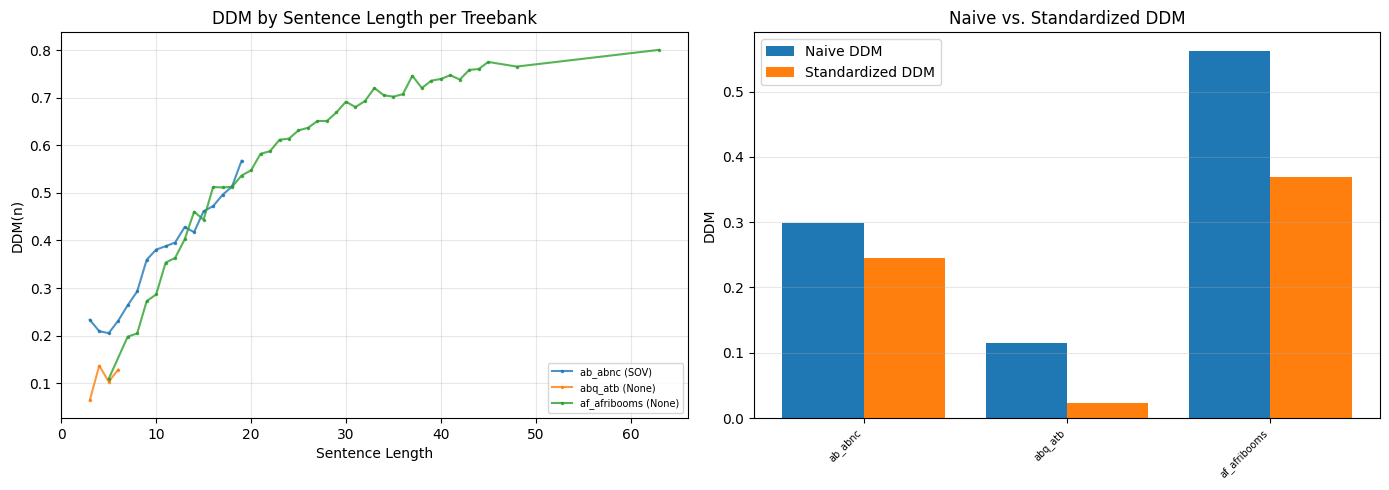

Saved ddm_visualization.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: DDM(n) curves per treebank
ax = axes[0]
for _, row in tb_df.iterrows():
    ddm_by_len = row['ddm_by_length']
    lengths = sorted(ddm_by_len.keys(), key=int)
    xs = [int(l) for l in lengths]
    ys = [ddm_by_len[l] for l in lengths]
    label = f"{row['treebank_id']} ({row.get('word_order', '?')})"
    ax.plot(xs, ys, marker='.', markersize=3, label=label, alpha=0.8)
ax.set_xlabel('Sentence Length')
ax.set_ylabel('DDM(n)')
ax.set_title('DDM by Sentence Length per Treebank')
ax.legend(fontsize=7, loc='lower right')
ax.grid(True, alpha=0.3)

# Plot 2: Naive vs Standardized DDM
ax2 = axes[1]
ax2.bar(range(len(tb_df)), tb_df['naive_ddm'], width=0.4, label='Naive DDM', align='center')
ax2.bar([x + 0.4 for x in range(len(tb_df))], tb_df['standardized_ddm'], width=0.4, label='Standardized DDM', align='center')
ax2.set_xticks([x + 0.2 for x in range(len(tb_df))])
ax2.set_xticklabels(tb_df['treebank_id'], rotation=45, ha='right', fontsize=7)
ax2.set_ylabel('DDM')
ax2.set_title('Naive vs. Standardized DDM')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ddm_visualization.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved ddm_visualization.png")